# Random-walk benchmarks — standalone prototype

A minimal, self-contained implementation of the two no-change benchmarks
(naive random walk and random walk with drift) on daily USDZAR, forecasting
4 weeks ahead from every Friday in 2021–2025.

This notebook predates the pipeline and is kept because its simplicity makes
the benchmark logic easy to follow end-to-end. The **official numbers** come
from the walk-forward pipeline (`src/backtest.py`, results in `reports/`),
which evaluates on the weekly Friday grid; small differences here come from
using daily data and nearest-trading-day targets. Reads the cached data in
`data/raw/`, so it runs without EconData credentials.

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
# Daily USDZAR from the repo's data cache (SARB series EXCX135 via EconData,
# downloaded once by `python run.py fetch`).
raw = pd.read_parquet('../data/raw/usdzar.parquet')
full_price = raw.set_index('date')['value'].sort_index().loc['2010-01-01':]

print(f"{len(full_price)} daily observations, "
      f"{full_price.index.min().date()} to {full_price.index.max().date()}")

4133 daily observations, 2010-01-04 to 2026-07-17


In [3]:
# Forecast origins: every Friday in the evaluation window (the task asks for
# a forecast each Friday). Horizon: 4 weeks, matching the pipeline's reading
# of "1 month ahead".
origins = pd.date_range('2021-01-01', '2025-12-31', freq='W-FRI')
horizon_offset = pd.DateOffset(weeks=4)
print(f"{len(origins)} Friday origins")

261 Friday origins


In [4]:
results = []

In [5]:
for origin in origins:
    # Expanding window: everything observable up to the origin. Drift (mu)
    # comes from the FULL history, not just the last month — a one-month
    # window makes the drift estimate wildly noisy and ruins the forecast.
    train_price = full_price.loc[:origin]
    if len(train_price) < 30:
        continue

    log_returns = np.log(train_price / train_price.shift(1)).dropna()
    mu = log_returns.mean()
    sigma = log_returns.std()

    # Anchor on the last TRUE value at/before the origin
    last_true_price = train_price.iloc[-1]
    last_true_date = train_price.index[-1]

    # Target: 4 weeks after the origin; use the first trading day on/after
    # it (markets can be shut on the exact date)
    target_date = origin + horizon_offset
    future_slice = full_price.loc[target_date:]
    if future_slice.empty:
        continue
    actual_date = future_slice.index[0]
    actual_value = future_slice.iloc[0]

    # Trading days between anchor and target, for compounding the drift
    horizon_days = (full_price.loc[last_true_date:actual_date]).shape[0] - 1
    if horizon_days <= 0:
        continue

    naive_forecast = last_true_price
    drift_forecast = last_true_price * np.exp(mu * horizon_days)

    results.append({
        'origin': origin,
        'last_true_date': last_true_date,
        'last_true_price': last_true_price,
        'target_date': actual_date,
        'actual_value': actual_value,
        'naive_forecast': naive_forecast,
        'drift_forecast': drift_forecast,
        'mu': mu,
        'sigma': sigma,
        'horizon_days': horizon_days,
    })

results_df = pd.DataFrame(results).set_index('origin')
print(f"{len(results_df)} forecasts")

261 forecasts


In [6]:
def rmse(forecast, actual):
    return np.sqrt(np.mean((forecast - actual) ** 2))

print(f"RMSE naive RW:      {rmse(results_df['naive_forecast'], results_df['actual_value']):.4f}")
print(f"RMSE RW with drift: {rmse(results_df['drift_forecast'], results_df['actual_value']):.4f}")
print("(pipeline equivalents on the weekly grid: 0.5600 / 0.5677 — see reports/)")

RMSE naive RW:      0.5601
RMSE RW with drift: 0.5663
(pipeline equivalents on the weekly grid: 0.5600 / 0.5677 — see reports/)


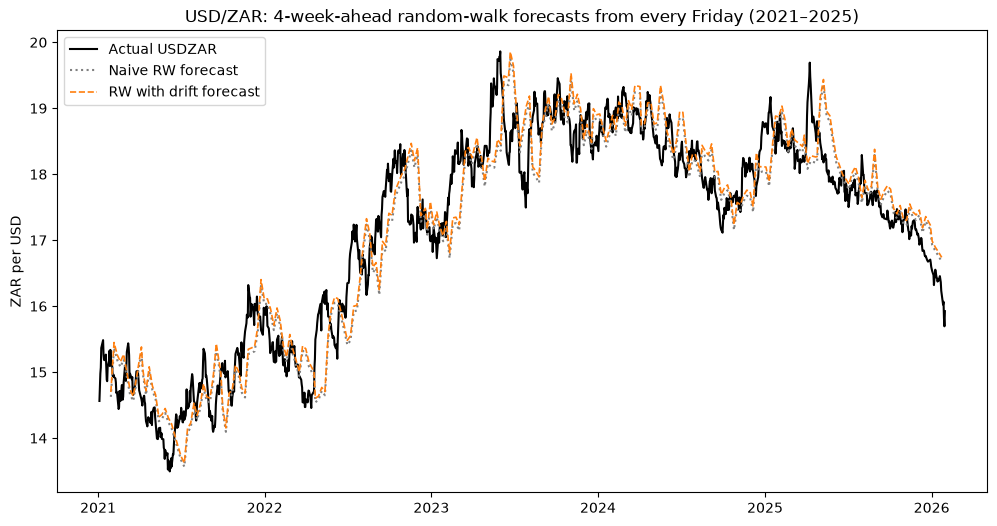

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(full_price.loc['2021-01-01':'2026-01-31'].index,
        full_price.loc['2021-01-01':'2026-01-31'].values,
        label="Actual USDZAR", color="black", linewidth=1.5)

# Forecasts are plotted at the date they are FOR (the target date). They
# resemble the actual shifted 4 weeks right because a no-change forecast
# just carries the origin value forward.
ax.plot(results_df['target_date'], results_df['naive_forecast'],
        label="Naive RW forecast", color="gray", linestyle=':', linewidth=1.5)
ax.plot(results_df['target_date'], results_df['drift_forecast'],
        label="RW with drift forecast", color="tab:orange", linestyle='--', linewidth=1.2)

ax.legend()
ax.set_title("USD/ZAR: 4-week-ahead random-walk forecasts from every Friday (2021–2025)")
ax.set_ylabel("ZAR per USD")
plt.show()

In [8]:
results_df.head(10)

,last_true_date,last_true_price,target_date,actual_value,naive_forecast,drift_forecast,mu,sigma,horizon_days
origin,,,,,,,,,
2021-01-01,2020-12-31,14.6246,2021-01-29,15.1903,14.6246,14.698164,0.000251,0.009968,20
2021-01-08,2021-01-08,15.3661,2021-02-05,14.9266,15.3661,15.448803,0.000268,0.009974,20
2021-01-15,2021-01-15,15.1810,2021-02-12,14.6610,15.1810,15.261217,0.000264,0.009970,20
2021-01-22,2021-01-22,15.0771,2021-02-19,14.5616,15.0771,15.155870,0.000261,0.009971,20
2021-01-29,2021-01-29,15.1903,2021-02-26,14.8367,15.1903,15.270343,0.000263,0.009975,20
2021-02-05,2021-02-05,14.9266,2021-03-05,15.3047,14.9266,15.003216,0.000256,0.009969,20
2021-02-12,2021-02-12,14.6610,2021-03-12,14.9757,14.6610,14.734212,0.000249,0.009963,20
2021-02-19,2021-02-19,14.5616,2021-03-19,14.6540,14.5616,14.633469,0.000246,0.009964,20
2021-02-26,2021-02-26,14.8367,2021-03-26,15.0113,14.8367,14.908033,0.000252,0.009966,19
